In [1]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # 新增：标准化工具
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. 加载数据
train = pd.read_csv('Train.csv')
df = train.drop('ID', axis=1)

# 2. 类别变量编码
df_prepared = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender'], drop_first=True)

# 3. 提取特征和目标
X = df_prepared.drop('Reached.on.Time_Y.N', axis=1)
y = df_prepared['Reached.on.Time_Y.N']

# 4. 划分数据集
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 重要：特征缩放 (Feature Scaling) ---
# 逻辑回归和 SVM 对数据范围很敏感，缩放后能解决不收敛警告
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 5. 定义模型 (修复了警告参数)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42), # 增加次数
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42) # 删除了废弃参数
}

# 6. 训练并对比
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

perf_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n--- 优化后的模型对比表 ---")
print(perf_df)


--- 优化后的模型对比表 ---
                 Model  Accuracy  F1-Score
0  Logistic Regression  0.636818  0.687769
3              XGBoost  0.644091  0.685921
1        Random Forest  0.658636  0.685115
2                  SVM  0.649091  0.662587


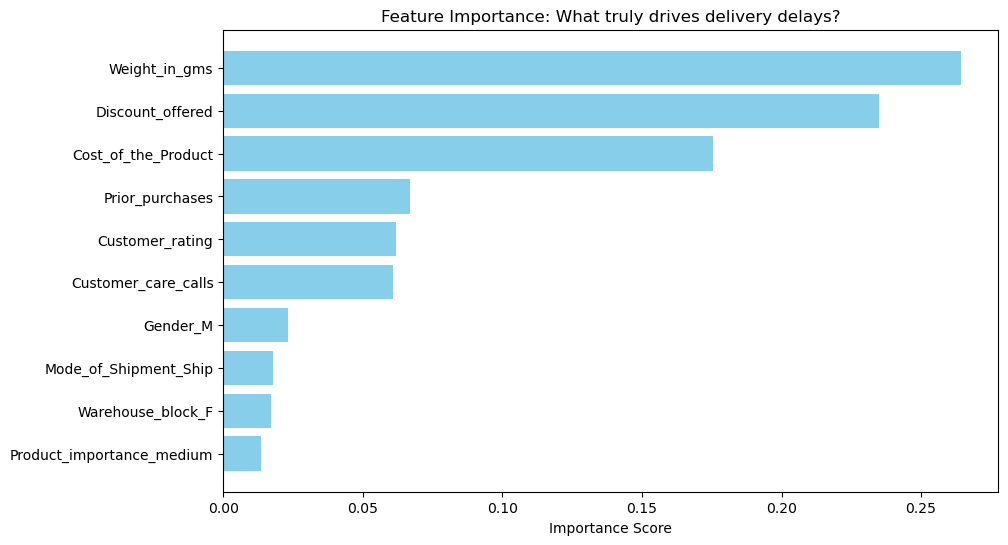

In [6]:
import matplotlib.pyplot as plt

# 假设 Random Forest 表现最好，我们查看它的特征重要性
best_model = models["Random Forest"]
importances = best_model.feature_importances_
feature_names = X.columns # X 是你处理后的特征名

# 排序并绘图
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance: What truly drives delivery delays?')
plt.xlabel('Importance Score')
plt.show()